In [1]:
# Auto-Reload for Fast Iteration
%load_ext autoreload
%autoreload 2

# --- Add project root (the dir that contains 'utils/') to sys.path ---
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "utils").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT)) # insert project root at the front of the search list
print("Project root:", ROOT)  # sanity check

# Import custom functions from utils package
from utils.models import VAE, CVAE
from utils.train_utils import (
    train_vae,
    loss_function,
    get_latent_mu,
    get_latent_mu_cvae,
    compute_condition_distances
)
from utils.data_utils import (
    load_all_fc_data,
    preprocess_for_torch
)
from utils.utils_plotting import (
    plot_vae_losses,
    plot_latent_embedding_by_condition_and_subject,
    plot_subject_distance_comparison
)
from utils.bootstrap import *   # common imports, DEVICE

Project root: /Users/liuq13/project-nodeap-fmri-cvae


In [2]:
DATA_DIR = (ROOT / "data").resolve()
sub_cond_path     = DATA_DIR / "SubConds.xlsx"
base_nifti_folder = DATA_DIR / "data_FC"
condition_map = {'N': 0, 'S': 1, 'C': 2}

In [3]:
# Load and preprocess
use_roi = 0
all_corr_data, all_tms_type, all_subject_id, all_stimloc, all_session = load_all_fc_data(sub_cond_path, 
                                                               base_nifti_folder, 
                                                               mat_filename='conn_matrix_w_sphere.mat',
                                                               key_name='correlation_matrix',row_idx=use_roi)
X_tensor = preprocess_for_torch(all_corr_data)


[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_30/S3D2/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_44/S1D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_83/S3D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_87/D0/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_88/D0/conn_matrix_w_sphere.mat
Columns with NaN: 14 / 116
Tensor shape after preprocessing: torch.Size([331, 102])


In [5]:
condition_list = np.array([condition_map[t] for t in all_tms_type]) # map tms type to 0,1,2
condition_tensor = torch.tensor(condition_list, dtype=torch.long)

# Create unique key: subject + condition
combo_keys = np.array([f"{s}_{c}" for s, c in zip(all_subject_id, condition_list)])
combo_counts = Counter(combo_keys)

weights = np.array([1.0 / combo_counts[k] for k in combo_keys]) # assign weights based on counts
weights_tensor = torch.DoubleTensor(weights) # convert to torch tensor

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
subject_labels = le.fit_transform(all_subject_id)
subject_tensor = torch.tensor(subject_labels, dtype=torch.long)

In [6]:
dataset = TensorDataset(X_tensor, subject_tensor, condition_tensor)
# create a weighted sampler that draws samples w/ prob proportional to weight
sampler = WeightedRandomSampler(weights_tensor, num_samples=len(weights_tensor), replacement=True)
# create a dataloader using the sampler instead of random shuffle
dataloader = DataLoader(dataset, batch_size=32, sampler=sampler)

In [7]:
# Set up model, optimizer, and device
input_dim = X_tensor.shape[1]
latent_dim = 10
NUM_EPOCH = 500
LR = 3e-4
model = VAE(input_dim=input_dim, latent_dim=latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
total_loss_hist, recon_loss_hist, kld_loss_hist = train_vae(model, dataloader, optimizer, device=DEVICE, epochs=NUM_EPOCH)


===== Epoch 1 =====


Epoch 1/500: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 281.18it/s]


Epoch 1, Loss: 105.4324, Recon: 105.0764, KL: 0.3560

===== Epoch 2 =====


Epoch 2/500: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 868.88it/s]


Epoch 2, Loss: 102.6838, Recon: 102.1657, KL: 0.5182

===== Epoch 3 =====


...

Epoch 498, Loss: 29.0503, Recon: 15.5499, KL: 13.5003

===== Epoch 499 =====


Epoch 499/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1019.07it/s]


Epoch 499, Loss: 28.5059, Recon: 14.9750, KL: 13.5309

===== Epoch 500 =====


Epoch 500/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1058.20it/s]


Epoch 500, Loss: 28.6090, Recon: 15.2605, KL: 13.3485


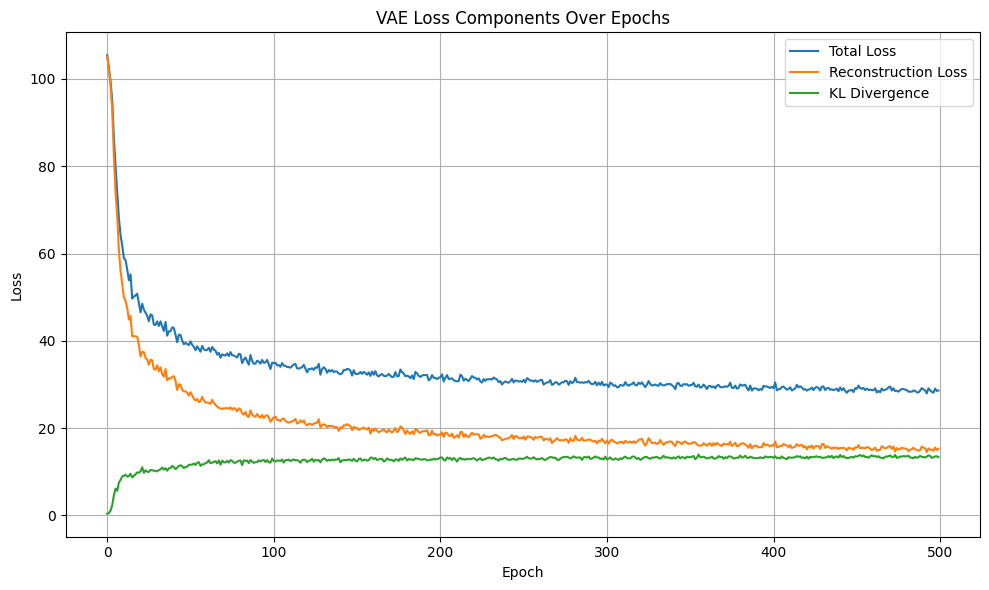

In [8]:
plot_vae_losses(total_loss_hist, recon_loss_hist, kld_loss_hist)

dim of latent mu: (331, 10)


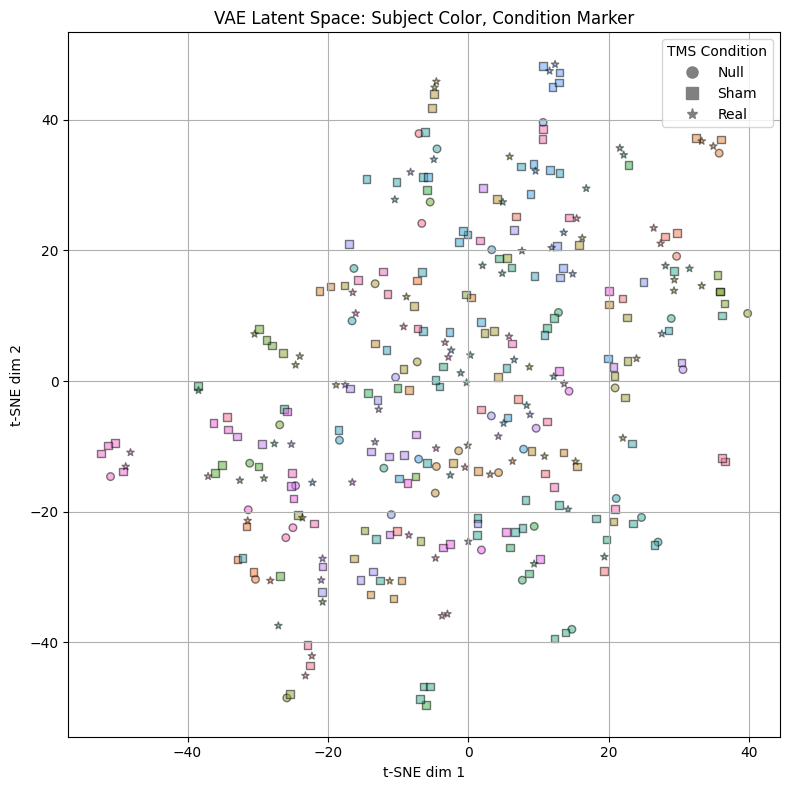

In [13]:
mu_all = get_latent_mu(model, X_tensor, device=DEVICE)
# 2d-TSNE
from sklearn.manifold import TSNE
z_2d = TSNE(n_components=2, perplexity=8).fit_transform(mu_all)
plot_latent_embedding_by_condition_and_subject(z_2d, all_tms_type, all_subject_id)

In [16]:
df = compute_condition_distances(mu_all, all_tms_type, all_subject_id, condition_map)

Paired t-test: t = -2.815, p = 0.0072


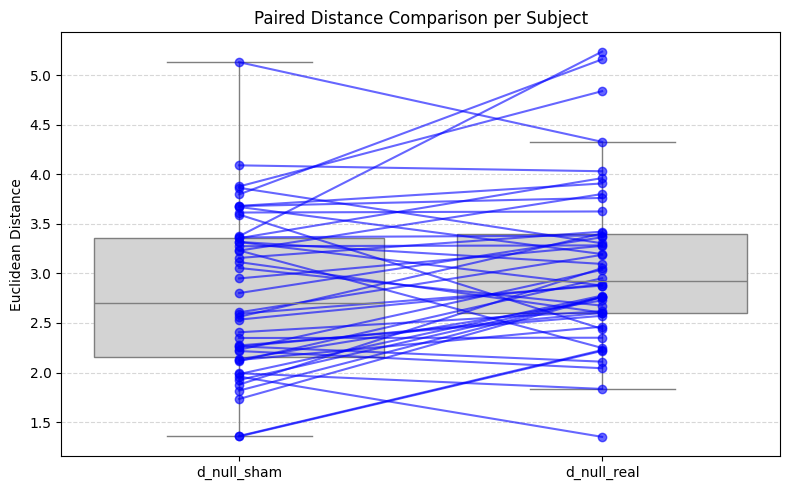

In [17]:
# Paired t-test
t_stat, p_val_t = ttest_rel(df["d_null_sham"], df["d_null_real"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.4f}")
plot_subject_distance_comparison(df)